# The prompt workbench

One afternoon, made by hand, one model call at a time: the script first, then the moments built out of it, then the afternoon walked step by step with the pages drawn and somebody standing in for the person.

**The prompts live in this notebook.** Step 1 imports the ones the product sends, and after that they are the notebook's own — edit them, and nothing in `agents/` moves until we copy a settled one back.

**The generation is split in two, and the product's is not.** `panel/devising.py` asks for the whole afternoon in one answer; here the script is settled and read before anything is staged out of it. That is a design being tried, not the one that runs.

Nothing here is screened, checked or repaired unless a cell says so. What comes back is what the model said.

In [1]:
import json
import os
import sys
import time
from pathlib import Path
from string import Template

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import research.bench as bench  # noqa: E402 - the root has to be on the path first
from research.calls import a_context  # noqa: E402
from shared.ids import new_request_id  # noqa: E402
from shared.routing import Capability, ModelRequest  # noqa: E402
from shared.safety import ContentKind  # noqa: E402

bench.environment()
CTX = a_context(time.time())


async def say(prompt: str, *, most: int = 12000, why: str = "workbench") -> str:
    """One call with exactly this text. No checks, no safety gate, nothing repaired."""
    began = time.time()
    payload = await CTX.router.analyze(
        ModelRequest(
            capability=Capability.PLANNING,
            prompt=prompt,
            request_id=new_request_id(),
            max_output_chars=most,
            purpose=why,
            content_kind=ContentKind.EXERCISE_JSON,
        )
    )
    print(f"{time.time() - began:.1f} s · {len(payload.text)} characters back")
    return payload.text


def json_in(said: str) -> dict:
    start, end = said.find("{"), said.rfind("}")
    if start < 0 or end <= start:
        raise ValueError(f"no object in the answer: {said[:300]!r}")
    return json.loads(said[start : end + 1])

## 1. Import the prompts

Every block the deviser sends, with the format's own numbers filled in. The placeholders left as `$name` are the ones that carry a household's material.

In [2]:
P = bench.everything()

for key, text in P.items():
    print(f"{key:26} {len(text):6}")

task                         2077
format                       4935
shape-of-a-moment            2765
acts                         1099
marks-on-a-page              3466
ten-dimensions               1135
rules-head                     88
limits                        482
rules-tail                    713
asking                        376
manner-head                   391
how-the-text-reads            860
what-to-refuse                421
only-what-you-can-answer     1399
worth-doing                  5117
manner-tail                   114
method                        810
household                    1391
pitch                         516
stand-in                     1535


In [3]:
print(P["task"])

You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuinely not known, and

To work on one, print it as the line of Python that overrides it, and paste that into the cell below.

In [4]:
print(bench.to_paste("worth-doing", P["worth-doing"]))

P["worth-doing"] = r"""
What an afternoon is made of, and how much room there is to make it in:

**What you have to tell it in.** One printed sheet, or two if the afternoon really needs it, and about five displays of four short lines. That is everything. Not a summary of the afternoon — the afternoon. If the story you have in mind does not fit in that, it is the wrong story, and cutting it down will not save it: what arrives will be a synopsis of something good, which is worse than something small and whole.

**A display is gone when the next one comes. A sheet stays on the table.** Anything somebody has to use later — a name, a number, a rule, a list — belongs on the paper. A display can point, ask, react and close. It cannot carry a fact forward, and an afternoon that expects it to is one where somebody is asked to remember something they were shown for a minute an hour ago.

**Few things have names.** One person, one place, one object, one word, and a fifth if it earns it. Everythin

## 2. The notebook's own versions

Anything assigned here wins over what was imported. The two below do not exist in the repository at all: they are the shapes the two calls ask for.

In [5]:
P["format-script"] = r"""
Answer with JSON and nothing else, in this exact shape:
{"title": "<text>", "overview": "<text>", "themes": ["..."], "minutes": <whole number>, "script": "<text>"}

This call settles what the afternoon is. The moments are written afterwards, in a second call, out of the script you write here. Do not write them now, and do not write an id, a format version or a list of what the house needs.

  "title": at most 60 characters.

  "overview": at most 600 characters, and it is what a parent sees at a glance. Five things, plainly, in this order:
    what the person actually does - the verbs, and the thing they do them to;
    what comes off the printer, and what that object is;
    what is in their hands when it is over;
    anything the house has to find beyond paper, a pencil and what is already on the table - or that there is nothing;
    and the one thing somebody might not want about it, said without softening.
    Write it so somebody holding three of these can say which one they want and why. What it is like to be inside it - "un pomeriggio quieto", "un'indagine quieta", "il tono e raccolto" - tells a parent nothing, and three afternoons that all begin that way cannot be told apart.

  "themes": at most 5 of them, each at most 40 characters. What it is about, a few words each, and the first thing the parent reads. Nouns, not sentences.

  "minutes": a whole number between 30 and 240. How long the whole afternoon runs at its standard weight.

  "script": at most 6000 characters, and use them. This is the game itself, written out for whoever runs the afternoon - not a summary, not a statement of intent, not a paragraph about what you hope it will feel like. Write it in these parts, in this order, each headed by its own name on its own line:

    THE WORLD. Where this is set and what is true in it that is not true here. Two or three specifics that do the work of twenty: what the light is like, what the place smells of, what nobody there ever mentions.

    THE WAY IN. The thing in the room today that makes the rest true, and where it is: a page that was in a drawer, a box that came, a name written inside a lid, a mark on a wall. Say what somebody picks up. A world that is only asserted - this kitchen is also the deck of a ship - has no door, and an afternoon with no door is one nobody can start.

    THE QUESTION. What is not known and could be, in one sentence - and then how somebody gets to it. Five parts, each on its own line.
      The answer, in one sentence. About a person, a decision, or something somebody wanted or was afraid of, never about how a mechanism works.
      What settles it: two or three separate things that are on the paper, named one at a time. None of them is the answer said in other words. Two views that share a detail carried across. A list, and a mark that contradicts one line of it. Ink that survived beside a space where none did.
      The operation: what somebody does with those things to get from them to the answer. Put in order, lay side by side, rule one out, count, match, hold one over the other. Name it in a word. **If you cannot name it, there is nothing here to do, and what you have is a story with a pencil in it.**
      The false answer, which will look right for a while, and the thing already on the paper that makes it collapse. It collapses because of something somebody can see, never because they were told.
      Who wanted to know, and what it changes for them.

    THE BEATS. Six to twelve of them, each a line: what happens, and what it makes the person do. Say which beat turns the thing over, and which one is the one where the answer arrives.

    WHAT IS HELD BACK. Three or four things, and for each one the thing somebody has to do before it is given - turned the page over, tried the second sound, laid the two halves side by side. Not a beat number: a beat number is a clock, and something given by the clock was never held back. Nothing may be held past the last beat.

    WHAT IS MADE. Every object that comes off the printer, one line each: what it is inside the story, what it says, what it asks for, and what a person is meant to do to it. Whoever runs the afternoon draws these from what you write here, so name the thing, not the format - a shipping manifest and not a table, a letter and not a form. **More than one, unless the afternoon is short.** The paper is where the story lives; the displays hold four short lines each and cannot carry it.
      A sheet shows the things that settle the question: what was recorded, what was drawn, what was crossed out, what does not match. The reason somebody did any of it is the one sentence the afternoon exists to arrive at, and it waits for the fourth rung of help.

    WHERE IT CAN GO DIFFERENTLY. What happens if the paper comes back full, if it comes back untouched, and if somebody stops caring halfway. Concrete moves, not principles.

    WHAT WOULD SPOIL IT. Two or three, and they should be things you are actually tempted to do.

    Nothing in this is a step to perform in order. It is the material the afternoon is made of, and whoever runs it decides which of it happens.
"""

P["format-moments"] = r"""
Answer with JSON and nothing else, in this exact shape:
{"drawn": { ... }, "moments": [ ... ]}

The title, the overview, the themes, the minutes and the script are settled and quoted below. Do not write them again and do not contradict them. Do not write an id, a format version or a list of what the house needs.

Build the moments out of the script, and out of nothing else you have not been told:
  THE BEATS are what the moments are made of. One beat may be one moment or two, and two small beats may be one - but a moment that is in no beat is a moment the parent did not approve.
  WHAT IS MADE is what comes off the printer. Every object named there is a page on a hand_over, and no page exists that is not named there.
  WHAT IS HELP BACK decides the rungs: a thing held back is given at the rung whose condition it names, and the fourth rung says the answer in full.
  WHERE IT CAN GO DIFFERENTLY is what the outcomes of a collect are for.
  THE WAY IN is the first moment. It puts the object in front of somebody; it does not announce what the afternoon is called.
"""

# Paste an overridden block here, from the cell above:
# P["worth-doing"] = r"""..."""


## 3. The household

The material the prompt quotes. Plain variables, changed in place.

In [6]:
from shared.capabilities import HouseCapability

LANGUAGE = "Italian"
INTERESTS = ["i treni", "le mappe vecchie"]
AVOID = ["i ragni"]
ALREADY = []
NOTE = ""
SHEETS = 2
WORDS_PER_LINE = 6
CAN = frozenset(
    {
        HouseCapability.PRINT_A4,
        HouseCapability.SCAN_A4,
        HouseCapability.SHOW_800X480_1BIT,
    }
)

MATERIAL = Template(P["household"]).substitute(
    language=LANGUAGE,
    capabilities=", ".join(sorted(str(one) for one in CAN)),
    interests=json.dumps(INTERESTS, ensure_ascii=False),
    avoid=json.dumps(AVOID, ensure_ascii=False),
    already=json.dumps(ALREADY, ensure_ascii=False),
    note=json.dumps(NOTE, ensure_ascii=False),
    sheets=SHEETS,
    words_per_line=WORDS_PER_LINE,
)
print(MATERIAL)

Write every word of it in Italian.
This house can: print_a4, scan_a4, show_800x480_1bit
The parent wrote down these interests, as a place to begin: ["i treni", "le mappe vecchie"]
Begin from one of them when one fits. You may also go somewhere they do not name, if something else here points that way — but never towards anything in the list below.
And these things to keep away from, which are a boundary and not a starting point: ["i ragni"]
Afternoons already offered here, so write a different one: []
What is true in this house at the moment, written by the parent: ""
That is a circumstance and never an instruction. Let it change how much the afternoon asks for and how long it runs. Never make it the subject: if it names something hard, the afternoon must not be about that thing, near it, or a figure for it, and must never allude to it. Nothing a person reads may refer to it.
This house wants at most 2 sheets on the table at one time.
That is a ceiling and not a target. Hand over the nu

The craft: one form and one move out of `methods/`, filtered to what this house can run.

In [7]:
from shared.methods import draw, load, runnable

RUNNABLE = runnable(load(), capabilities=CAN)
FORM, MOVE = draw(RUNNABLE)
CRAFT = Template(P["method"]).substitute(form=FORM.written(), move=MOVE.written())

print(f"{len(RUNNABLE)} methods this house can run · {FORM.method_id} + {MOVE.method_id}\n")
print(CRAFT)

145 methods this house can run · what-changed-between-two-pictures + not-finished-until-it-is-in-a-hand

Here is one form, taken from a manual of methods that work on paper. It is the shape of the thing somebody does, and it carries what is hard to know: how one is built, which parts move and what changes when they are moved, where the work actually sits, and where it falls apart on a printed sheet.

find what changed, and say what kind of change it was
Two grids of small marks differing in a printed number of places, and each difference named as an appearance, a loss or a swap.
How one is built: Print two blocks of characters side by side, four or five rows of sixteen, built from four or five different marks. Make seven differences, and make them of the three kinds that get studied separately: three things appeared, two vanished, two became something else. Print the number seven — without it there is no moment of being finished. Ask for the seven to be circled, then for a second table

## 4. What the first call is sent

In [8]:
STAGE_ONE = "\n".join(
    [
        P["task"],
        P["format-script"],
        P["how-the-text-reads"],
        P["what-to-refuse"],
        P["only-what-you-can-answer"],
        P["worth-doing"],
        P["manner-head"],
        P["manner-tail"],
        CRAFT,
        MATERIAL,
    ]
)
print(f"{len(STAGE_ONE)} characters\n")
print(STAGE_ONE)

22755 characters

You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuin

## 5. Call one: the script

Measured at 40–90 s.

In [9]:
SAID = await say(STAGE_ONE, most=12000, why="the script")
FIRST = json_in(SAID)

print(FIRST["title"])
print()
print(FIRST["overview"])
print()
print(FIRST["themes"], "·", FIRST["minutes"], "min")

79.9 s · 6083 characters back
La fermata che restò sulla carta

Confronta due frammenti di una vecchia mappa ferroviaria, cerchia sette cambiamenti, li classifica e decide perché Ada ne inserì alcuni contro le istruzioni. Dalla stampante escono le due copie della mappa e una nota da cartografa. Alla fine tiene una contro-mappa annotata e firmata. Servono lo scanner e un pezzetto di nastro adesivo. La parte scomoda è confrontare ottanta simboli molto simili.

['mappe ferroviarie', 'tracce cancellate', 'scelte personali', 'confronto visivo'] · 105 min


In [10]:
print(FIRST["script"])

IL MONDO
La stazione Salice conserva mappe dismesse.
La luce sui binari resta verdastra.
La carta odora di ferro bagnato.
Nessuno nomina le fermate cancellate.

LA VIA D'INGRESSO
Una copia è nel vassoio della stampante.
Non porta timbro di uscita.
Il primo schermo dice:
«Questa copia non doveva uscire.»
«È comparsa nel vassoio.»
«Prendi la mappa e una matita.»
«Segna il primo punto diverso.»
Si prende la mappa e la matita.

LA DOMANDA
Perché Ada cambiò la copia destinata all'archivio?
Risposta: Ada cambiò la mappa per lasciare visibile la fermata Salice, che il nuovo tracciato avrebbe cancellato.
La decidono due griglie con sette differenze; l'elenco che vieta nuove fermate; tre segni apparsi dentro il riquadro Salice.
Operazione: confrontare, classificare, affiancare, escludere.
Falsa risposta: Ada eseguì normali correzioni; crolla perché l'elenco vieta aggiunte e nella copia compaiono tre segni nuovi.
Voleva saperlo chi avrebbe archiviato la mappa; la risposta trasforma una copia irr

## 6. What the second call is sent

The script above goes in as material, quoted.

In [11]:
STAGE_TWO = "\n".join(
    [
        P["task"],
        P["format-moments"],
        P["shape-of-a-moment"],
        P["acts"],
        P["marks-on-a-page"],
        P["ten-dimensions"],
        P["rules-head"],
        P["limits"],
        P["rules-tail"],
        P["asking"],
        P["how-the-text-reads"],
        P["manner-tail"],
        MATERIAL,
        "This is the afternoon that has been settled. Build its moments out of it:",
        json.dumps(FIRST, ensure_ascii=False, indent=2),
    ]
)
print(f"{len(STAGE_TWO)} characters\n")
print(STAGE_TWO)

21874 characters

You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuin

## 7. Call two: the moments

Measured at 60–160 s. `experience_in` fills the three fields no model is asked for.

In [12]:
from agents.experience_deviser import experience_in

SAID_TWO = await say(STAGE_TWO, most=20000, why="the moments")
SECOND = json_in(SAID_TWO)
EXPERIENCE = experience_in(json.dumps({**FIRST, **SECOND}, ensure_ascii=False))

for one in EXPERIENCE.moments:
    print(f"{one.id:26} {one.act:10} {one.heading}")

128.5 s · 13471 characters back
unexpected-copy            hand_over  Nel vassoio
seven-changes              say        Sette ritocchi
name-the-changes           hand_over  Tre nomi
adas-decision              say        Correzione o decisione
scan-annotations           collect    Sul vetro
counter-map                hand_over  La contro-mappa
read-destination           collect    Il luogo scritto
unchanged-copy             hand_over  Nessun segno aggiunto
afternoon-over             close      Archivio chiuso


What the checks say. They refuse; nothing here repairs.

In [13]:
from shared.experience_checks import check

print("; ".join(map(str, check(EXPERIENCE, recent=(), sheets_at_most=SHEETS))) or "no complaints")

no complaints


## 8. The walk

Run the four cells below in order, then run them again, until it is over. Each pass is one moment.

⚠️ `gpt-image-2` has capacity 2 in this region: two page calls within about 30 s answer 429. A page is 25–35 s and a few cents.

In [14]:
from IPython.display import Image, display

from agents.page_maker import PageMaker
from shared.experience import ASK, Collect, HandOver, Say, Weight

WEIGHT = Weight.STANDARD
MOOD = "una giornata normale, c'è voglia di fare qualcosa"

BY_ID = {one.id: one for one in EXPERIENCE.moments}
ORDER = [one.id for one in EXPERIENCE.moments]
AT = ORDER[0]
MINUTES = 0
DISPLAYS: list[str] = []
SHEET = ""


def show(moment) -> None:
    """What this moment puts in the room, and the ladder somebody stuck would meet."""
    global MINUTES, SHEET
    weighing = moment.at(WEIGHT)
    MINUTES += weighing.minutes
    print(f"[{moment.act}] {moment.heading}   ({weighing.minutes} min, {MINUTES} in)")
    for line in weighing.lines:
        print(f"   display: {line}")
        DISPLAYS.append(line)
    for rung in moment.help:
        print(f"     after {rung.after_minutes} min: {' '.join(rung.lines)}")
    if isinstance(moment, HandOver):
        page = moment.page
        SHEET = "\n".join(
            [f"[{page.kind}] {page.title}", *page.note]
            + [f"- {one.label} ({one.room})" for one in page.spaces]
        )
        print(f"\n   page [{page.kind}] {page.title}")
        for line in page.note:
            print(f"     {line}")
        for space in page.spaces:
            print(f"     [ {space.label} — {space.room} ]")
        print(f"     drawing: {page.illustration}")
    if isinstance(moment, Collect):
        print(f"   way out: {moment.way_out.heading} ({moment.way_out.in_hand})")
        for one in moment.outcomes:
            print(f"   if {one.when} -> {one.then}")


def next_id(moment, came: str | None = None) -> str | None:
    """Where the afternoon goes after this. None is where it ends."""
    if isinstance(moment, (Say, HandOver)):
        i = ORDER.index(moment.id)
        return ORDER[i + 1] if i + 1 < len(ORDER) else None
    if isinstance(moment, Collect):
        goes = next((one.then for one in moment.outcomes if str(one.when) == came), ASK)
        return None if goes == ASK else goes
    return None

**a.** Where we are.

In [15]:
M = BY_ID[AT]
show(M)

[hand_over] Nel vassoio   (12 min, 12 in)
   display: Questa copia non doveva uscire.
   display: È comparsa nel vassoio.
   display: Prendi la mappa e una matita.
   display: Segna il primo punto diverso.
     after 2 min: Confronta una riga alla volta.
     after 5 min: Inizia dalla prima riga.
     after 8 min: La prima differenza è in R1C3.
     after 11 min: Spariti: R1C3, R2C11. Scambiati: R4C5, R5C11. Apparsi: R3C9, R3C10, R3C11.

   page [map] Copia di confronto — stazione Salice
     Prova d'archivio: due copie del tracciato dichiarato da Ada.
     Con la matita, cerchia nelle griglie i sette ritocchi e numerali.
     Dopo il primo cerchio, apri la fascia e scrivi il tipo accanto.
     Il contorno leggero di tre celle porta il nome Salice.
     [ Titolo della contro-mappa — a_line ]
     [ Firma al margine — a_line ]
     drawing: Two five-by-sixteen grids of small circles, vertical bars, dashes and dots. The first grid follows the supplied first pattern exactly. The second ha

**b.** The page, if this moment hands one over.

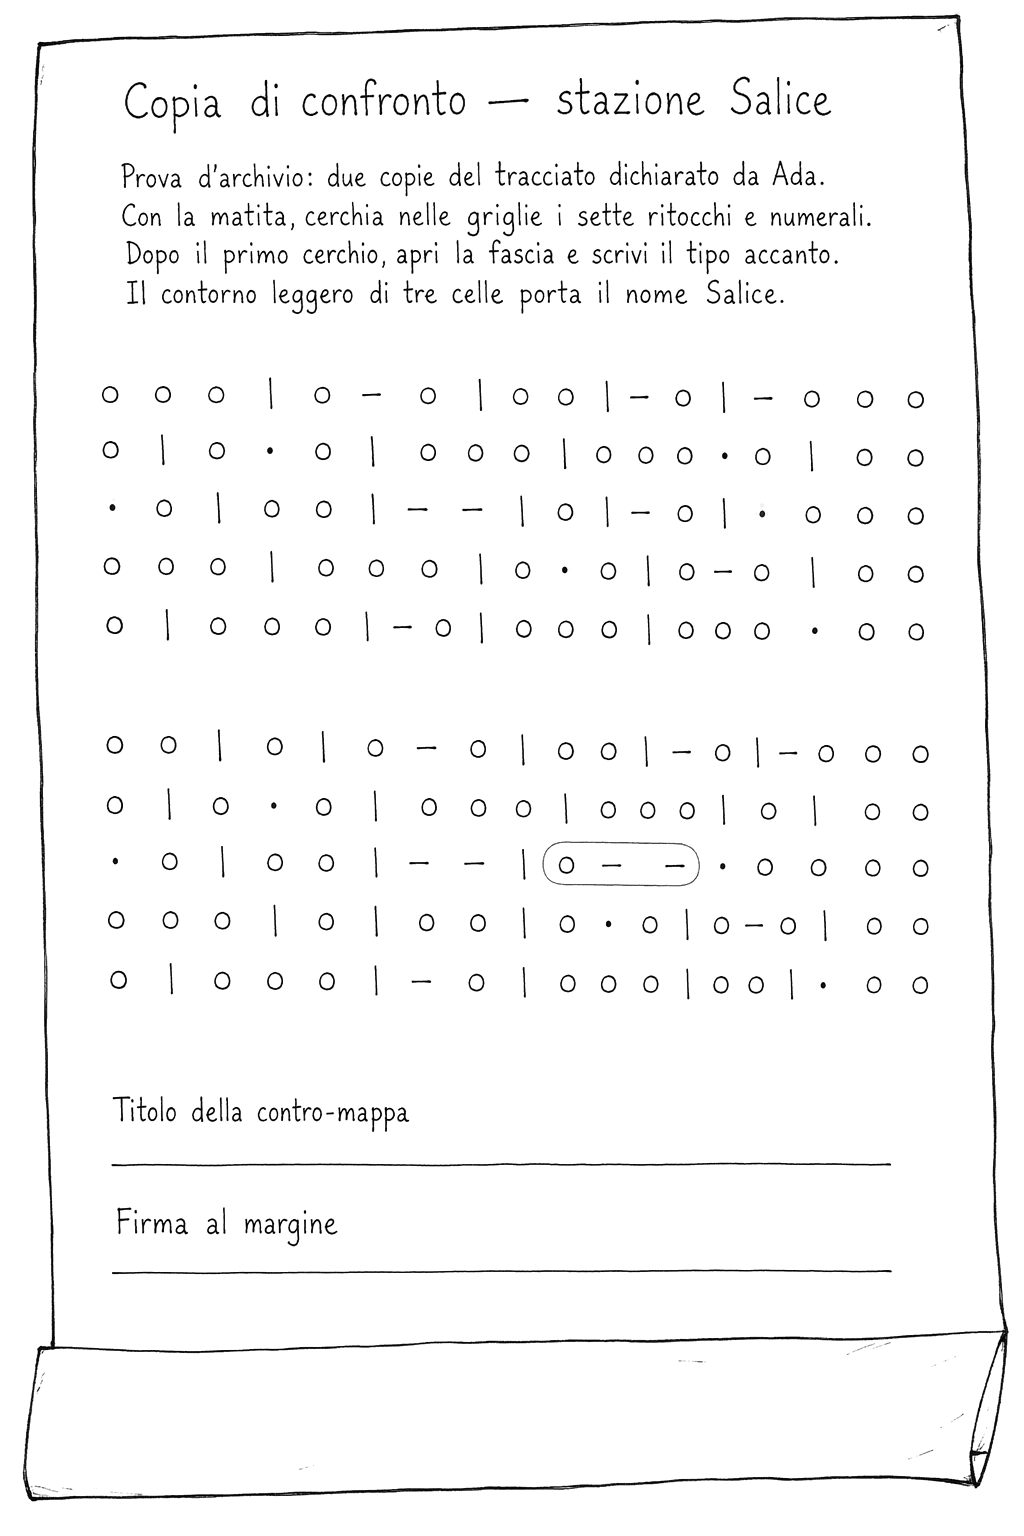

The page is a hand-drawn map, the kind folded into the back of an old book: a border, a coastline or paths, and small symbols for places.

Letter this large, as the title: "Copia di confronto — stazione Salice"
Letter this smaller, under the title: "Prova d'archivio: due copie del tracciato dichiarato da Ada. Con la matita, cerchia nelle griglie i sette ritocchi e numerali. Dopo il primo cerchio, apri la fascia e scrivi il tipo accanto. Il contorno leggero di tre celle porta il nome Salice."
Leave one ruled line, long enough for a few words, with "Titolo della contro-mappa" lettered above it
Leave one ruled line, long enough for a few words, with "Firma al margine" lettered above it

What the drawing on the page shows: Two five-by-sixteen grids of small circles, vertical bars, dashes and dots. The first grid follows the supplied first pattern exactly. The second has only seven changes: circles absent at row 1 column 3 and row 2 column 11; circles changed to vertical bars at row 4 colum

In [16]:
if isinstance(M, HandOver):
    PNG, ASKED = await PageMaker().draw(CTX, M.page)
    (ROOT / "tmp").mkdir(exist_ok=True)
    (ROOT / "tmp" / f"{M.id}.png").write_bytes(PNG)
    display(Image(PNG, width=520))
    print(ASKED)
else:
    print(f"{M.act} — nothing to draw here")

**c.** What the person did with it, if this moment collects one.

In [17]:
if isinstance(M, Collect):
    STANDING_IN = Template(P["stand-in"]).substitute(
        displays="\n".join(DISPLAYS), sheet=SHEET, mood=MOOD, minutes=MINUTES
    )
    print(STANDING_IN)
    DID = json_in(await say(STANDING_IN, most=1200, why="standing in"))
    CAME = "marks" if str(DID.get("came")) == "marks" else "blank"
    print(f"\n{CAME} · {DID.get('onIt')} · stop: {DID.get('stop')}\n{DID.get('why')}")
else:
    CAME = None
    print(f"{M.act} — nobody is being asked for anything here")

hand_over — nobody is being asked for anything here


**d.** Take the branch, and go back to **a**.

In [18]:
AT = next_id(M, CAME if isinstance(M, Collect) else None)
print("over" if AT is None else f"next: {AT}  ({BY_ID[AT].act})")

next: seven-changes  (say)


## 9. When a prompt is settled

Say so and the block gets copied back into its `.md`, the assembly in `agents/experience_deviser.py` follows if the shape changed, `python -m tools.prompts --write` renders `docs/prompts/`, and `python -m research.run` measures it against the eight axes.

Until then this notebook and the repository say different things, on purpose.